In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import silhouette_score

In [1]:
from google.colab import drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
root_dir = '/content'
os.chdir(root_dir)

In [9]:
df = pd.read_csv("Mall_Customers.csv")


In [10]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [12]:
print(df.columns)

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')


In [15]:
encoder = LabelEncoder()

df['Genre'] = encoder.fit_transform(df['Genre'])

In [16]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [17]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [18]:
kmeans = KMeans(n_clusters=5, random_state=42)

kmeans_labels = kmeans.fit_predict(X_scaled)

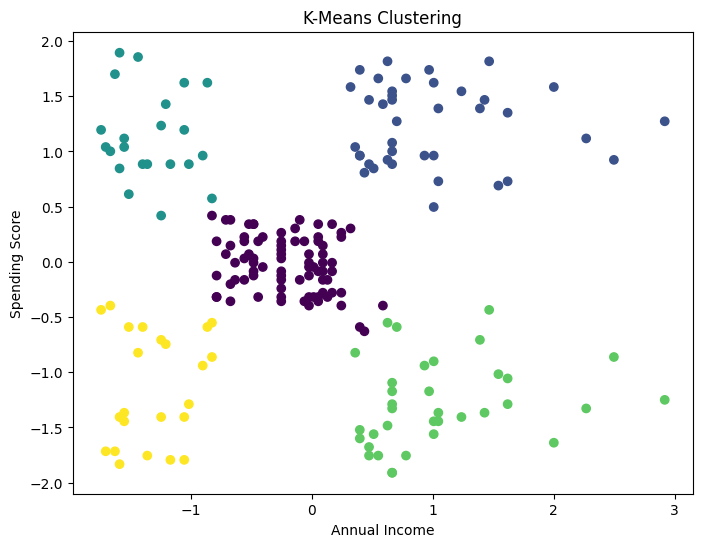

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=kmeans_labels
)

plt.xlabel("Annual Income")

plt.ylabel("Spending Score")

plt.title("K-Means Clustering")

plt.show()

In [20]:
score = silhouette_score(X_scaled, kmeans_labels)

print("Silhouette Score:", score)

Silhouette Score: 0.5546571631111091


In [21]:
agg = AgglomerativeClustering(n_clusters=5)

agg_labels = agg.fit_predict(X_scaled)

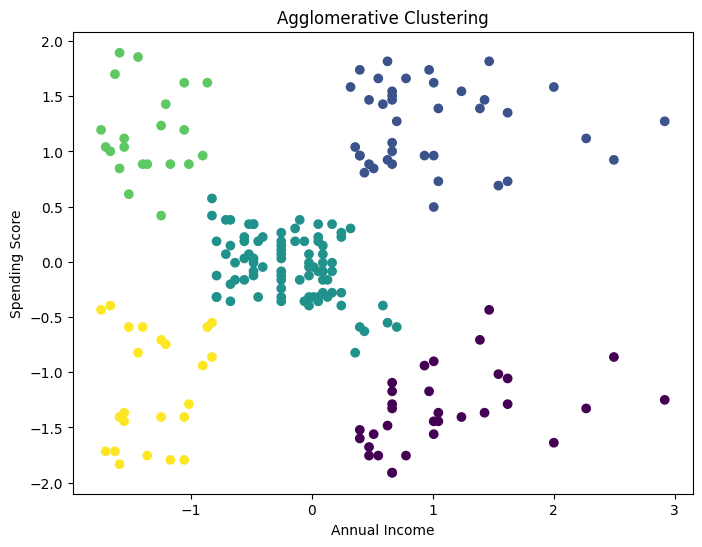

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=agg_labels
)

plt.xlabel("Annual Income")

plt.ylabel("Spending Score")

plt.title("Agglomerative Clustering")

plt.show()

In [23]:
score2 = silhouette_score(X_scaled, agg_labels)

print("Silhouette Score:", score2)

Silhouette Score: 0.5538089226688662


In [24]:
print("K-Means Silhouette Score :", score)

print("Agglomerative Silhouette Score :", score2)

K-Means Silhouette Score : 0.5546571631111091
Agglomerative Silhouette Score : 0.5538089226688662


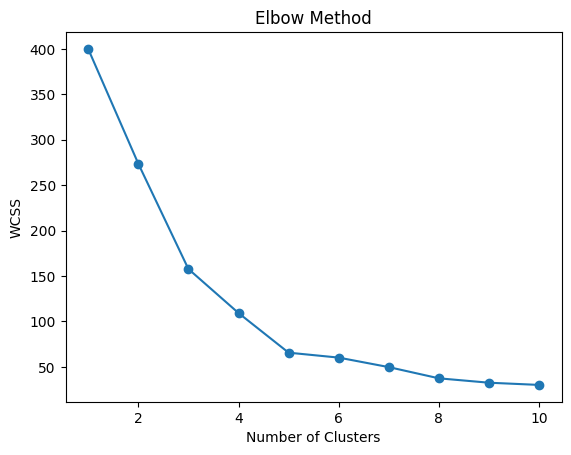

In [25]:
wcss = []

for i in range(1,11):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()